In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,roc_auc_score,
average_precision_score, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [104]:
df = pd.read_csv('open-meteo-26.96N75.82E438m (1).csv', skiprows=3)

In [105]:
df.columns = [
    'time', 'weather_code', 'temp_mean', 'temp_max', 'temp_min',
    'precipitation_sum', 'rain_sum', 'wind_speed_max',
    'humidity_max', 'humidity_min', 'humidity_mean',
    'wind_speed_min', 'wind_speed_mean'
]
df.head()

,time,weather_code,temp_mean,temp_max,temp_min,precipitation_sum,rain_sum,wind_speed_max,humidity_max,humidity_min,humidity_mean,wind_speed_min,wind_speed_mean
0,2015-01-19,1,13.8,20.6,7.0,0.0,0.0,8.9,93,38,68,2.6,6.7
1,2015-01-20,3,14.1,20.7,8.3,0.0,0.0,18.3,94,39,68,7.8,11.9
2,2015-01-21,51,15.5,21.2,11.4,0.5,0.5,16.9,90,57,76,7.0,13.0
3,2015-01-22,61,15.2,19.0,12.6,8.0,8.0,14.1,96,72,87,2.2,6.9
4,2015-01-23,51,14.7,18.0,12.0,0.5,0.5,8.3,99,64,87,2.1,5.5


In [106]:
df.shape

(3972, 13)

In [107]:
df.isnull().sum()

time                 0
weather_code         0
temp_mean            0
temp_max             0
temp_min             0
precipitation_sum    0
rain_sum             0
wind_speed_max       0
humidity_max         0
humidity_min         0
humidity_mean        0
wind_speed_min       0
wind_speed_mean      0
dtype: int64

In [108]:
df['time'] = pd.to_datetime(df['time'])
df['year']  = df['time'].dt.year
df['month'] = df['time'].dt.month

In [109]:
df = df.drop(columns=[
    'rain_sum', 'humidity_max', 'humidity_min',
    'wind_speed_max', 'wind_speed_min', 'weather_code'
])

In [110]:
df['heatwave'] = (df['temp_max'] >= 40).astype(int)
df['heatwave'].value_counts()

heatwave
0    3652
1     320
Name: count, dtype: int64

In [111]:
df['heatwave'].value_counts(normalize=True) * 100

heatwave
0    91.943605
1     8.056395
Name: proportion, dtype: float64

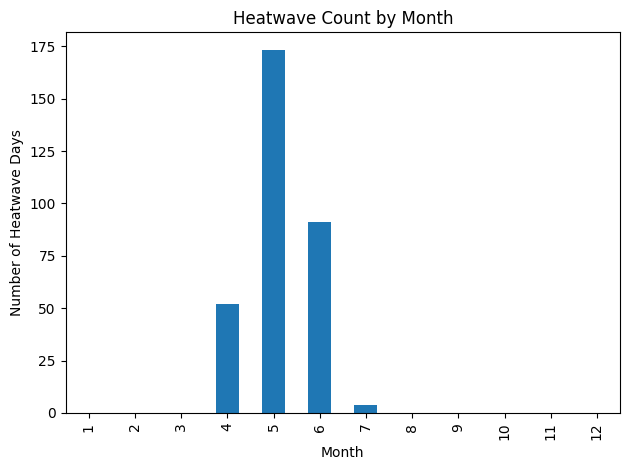

In [112]:
monthly_heatwave = df.groupby('month')['heatwave'].sum()

plt.figure()
monthly_heatwave.plot(kind='bar')
plt.title('Heatwave Count by Month')
plt.xlabel('Month')
plt.ylabel('Number of Heatwave Days')
plt.tight_layout()
plt.show()

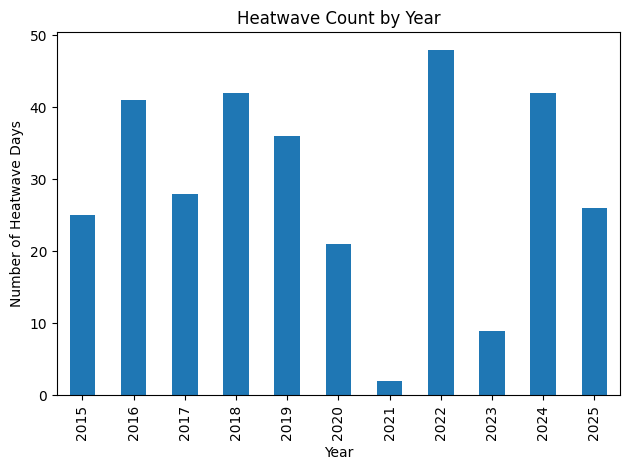

In [113]:
yearly_heatwave = df.groupby('year')['heatwave'].sum()

plt.figure()
yearly_heatwave.plot(kind='bar')
plt.title('Heatwave Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Heatwave Days')
plt.tight_layout()
plt.show()

In [114]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
print('Month cyclical encoding done.')
df[['month', 'month_sin', 'month_cos']].drop_duplicates().sort_values('month')

Month cyclical encoding done.


,month,month_sin,month_cos
0,1,5.000000e-01,8.660254e-01
13,2,8.660254e-01,5.000000e-01
41,3,1.000000e+00,6.123234e-17
72,4,8.660254e-01,-5.000000e-01
102,5,5.000000e-01,-8.660254e-01
133,6,1.224647e-16,-1.000000e+00
163,7,-5.000000e-01,-8.660254e-01
194,8,-8.660254e-01,-5.000000e-01
225,9,-1.000000e+00,-1.836970e-16
255,10,-8.660254e-01,5.000000e-01


In [115]:
df['temp_min_lag1']  = df['temp_min'].shift(1)
df['temp_mean_lag1'] = df['temp_mean'].shift(1)
df['temp_max_lag1']  = df['temp_max'].shift(1)
df['humidity_lag1']  = df['humidity_mean'].shift(1)
df['precip_lag1']    = df['precipitation_sum'].shift(1)
df['wind_lag1']      = df['wind_speed_mean'].shift(1)


df['temp_max_lag2']  = df['temp_max'].shift(2)

df['temp_max_lag3']  = df['temp_max'].shift(3)

df['temp_mean_3d_avg'] = df['temp_mean'].shift(1).rolling(window=3).mean()
df['temp_max_5d_avg']  = df['temp_max'].shift(1).rolling(window=5).mean()

df = df.dropna()
print(f'Rows after dropna: {len(df)}')
df.head()

Rows after dropna: 3967


,time,temp_mean,temp_max,temp_min,precipitation_sum,humidity_mean,wind_speed_mean,year,month,heatwave,...,temp_min_lag1,temp_mean_lag1,temp_max_lag1,humidity_lag1,precip_lag1,wind_lag1,temp_max_lag2,temp_max_lag3,temp_mean_3d_avg,temp_max_5d_avg
5,2015-01-24,13.2,18.0,9.5,0.0,76,6.0,2015,1,0,...,12.0,14.7,18.0,87.0,0.5,5.5,19.0,21.2,15.133333,19.90
6,2015-01-25,13.7,18.9,7.7,0.0,72,6.5,2015,1,0,...,9.5,13.2,18.0,76.0,0.0,6.0,18.0,19.0,14.366667,19.38
7,2015-01-26,14.1,17.8,11.6,0.0,74,5.7,2015,1,0,...,7.7,13.7,18.9,72.0,0.0,6.5,18.0,18.0,13.866667,19.02
8,2015-01-27,13.2,18.0,9.2,0.0,68,6.6,2015,1,0,...,11.6,14.1,17.8,74.0,0.0,5.7,18.9,18.0,13.666667,18.34
9,2015-01-28,11.3,16.7,6.7,0.0,66,8.5,2015,1,0,...,9.2,13.2,18.0,68.0,0.0,6.6,17.8,18.9,13.666667,18.14


In [116]:
features = [
    'temp_min_lag1',
    'temp_mean_lag1',
    'temp_max_lag1',
    'temp_max_lag2',
    'temp_max_lag3',
    'humidity_lag1',
    'wind_lag1',
    'precip_lag1',
    'temp_mean_3d_avg',
    'temp_max_5d_avg',
    'month_sin',
    'month_cos',
]

X = df[features]
y = df['heatwave']
print(f'Total features: {len(features)}')

Total features: 12


In [117]:
train_df = df[df['year'] <= 2022]
test_df  = df[df['year'] >  2022]

X_train = train_df[features]
y_train = train_df['heatwave']
X_test  = test_df[features]
y_test  = test_df['heatwave']

print(f'Train: {len(X_train)} rows ({y_train.sum()} heatwave days)')
print(f'Test:  {len(X_test)} rows ({y_test.sum()} heatwave days)')

Train: 2899 rows (243 heatwave days)
Test:  1068 rows (77 heatwave days)


In [118]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [119]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_sc, y_train)
y_pred_lr = lr_model.predict(X_test_sc)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[947  44]
 [  1  76]]

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       991
           1       0.63      0.99      0.77        77

    accuracy                           0.96      1068
   macro avg       0.82      0.97      0.87      1068
weighted avg       0.97      0.96      0.96      1068



In [120]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

# Overfitting check
train_acc = rf_model.score(X_train, y_train)
test_acc  = rf_model.score(X_test, y_test)
print(f'Train accuracy: {train_acc:.3f}')
print(f'Test accuracy:  {test_acc:.3f}')

Confusion Matrix:
[[966  25]
 [  5  72]]

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       991
           1       0.74      0.94      0.83        77

    accuracy                           0.97      1068
   macro avg       0.87      0.95      0.91      1068
weighted avg       0.98      0.97      0.97      1068

Train accuracy: 0.976
Test accuracy:  0.972


In [121]:
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print('=== Random Forest ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_proba_rf):.3f}')

print('\n=== Logistic Regression ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_proba_lr):.3f}')

print('\nGuide: ROC-AUC > 0.85 = good | PR-AUC > 0.5 = decent for imbalanced data')

=== Random Forest ===
ROC-AUC: 0.986
PR-AUC:  0.890

=== Logistic Regression ===
ROC-AUC: 0.993
PR-AUC:  0.913

Guide: ROC-AUC > 0.85 = good | PR-AUC > 0.5 = decent for imbalanced data


Default threshold (0.5) F1: 0.828
Best threshold:             0.604
Best threshold F1:          0.848

Confusion Matrix (tuned threshold):
[[973  18]
 [  7  70]]

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       991
           1       0.80      0.91      0.85        77

    accuracy                           0.98      1068
   macro avg       0.89      0.95      0.92      1068
weighted avg       0.98      0.98      0.98      1068



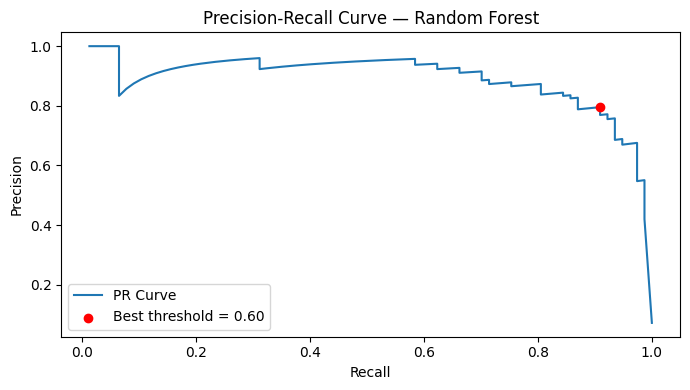

In [122]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

f1_scores     = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx      = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

default_idx = np.argmin(abs(thresholds - 0.5))
print(f'Default threshold (0.5) F1: {f1_scores[default_idx]:.3f}')
print(f'Best threshold:             {best_threshold:.3f}')
print(f'Best threshold F1:          {f1_scores[best_idx]:.3f}')

y_pred_rf_tuned = (y_proba_rf >= best_threshold).astype(int)
print('\nConfusion Matrix (tuned threshold):')
print(confusion_matrix(y_test, y_pred_rf_tuned))
print()
print(classification_report(y_test, y_pred_rf_tuned))

plt.figure(figsize=(7, 4))
plt.plot(recalls[:-1], precisions[:-1], label='PR Curve')
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5,
            label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

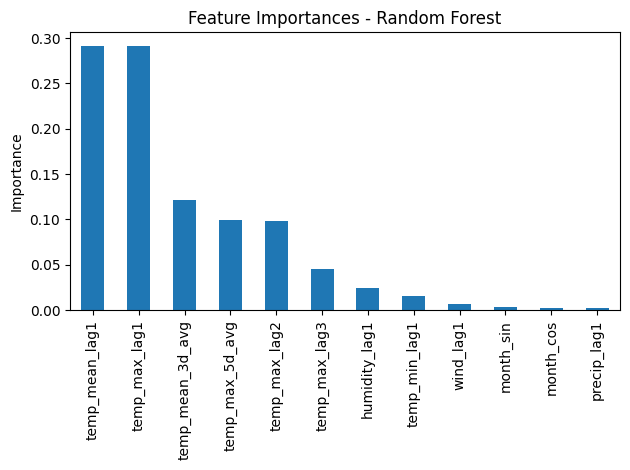

In [123]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure()
importances.plot(kind='bar')
plt.title('Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [124]:
df['temp_max_tomorrow'] = df['temp_max'].shift(-1)

df_reg = df.dropna(subset=['temp_max_tomorrow']).copy()

In [125]:
reg_features = [      
    'temp_max_lag1',   
    'temp_max_lag2',   
    'temp_max_5d_avg', 
    'temp_mean',       
    'temp_min',        
    'humidity_mean',
    'wind_speed_mean',
    'precipitation_sum',
    'month_sin',
    'month_cos',
]

X_reg = df_reg[reg_features]
y_reg = df_reg['temp_max_tomorrow']


In [126]:
correlations = X_reg.corrwith(y_reg).sort_values(ascending=False)
print('Correlation with target: ')
print(correlations.round(3))

Correlation with target: 
temp_mean            0.947
temp_max_lag1        0.943
temp_max_5d_avg      0.926
temp_max_lag2        0.919
temp_min             0.855
wind_speed_mean      0.350
month_sin            0.003
precipitation_sum   -0.039
humidity_mean       -0.472
month_cos           -0.766
dtype: float64


In [127]:
train_reg = df_reg[df_reg['year'] <= 2022]
test_reg  = df_reg[df_reg['year'] >  2022]

X_train_reg = train_reg[reg_features]
y_train_reg = train_reg['temp_max_tomorrow']
X_test_reg  = test_reg[reg_features]
y_test_reg  = test_reg['temp_max_tomorrow']

print(f'Train: {len(X_train_reg)} rows')
print(f'Test:  {len(X_test_reg)} rows')

Train: 2899 rows
Test:  1067 rows


In [128]:
baseline_pred = np.full(len(y_test_reg), y_train_reg.mean())
baseline_mae  = mean_absolute_error(y_test_reg, baseline_pred)
print(f'\nBaseline MAE (always predict mean): {baseline_mae:.2f} degree C')


Baseline MAE (always predict mean): 4.69 degree C


In [129]:
scaler_reg   = StandardScaler()
X_train_sc_r = scaler_reg.fit_transform(X_train_reg)
X_test_sc_r  = scaler_reg.transform(X_test_reg)

lr_reg = LinearRegression()
lr_reg.fit(X_train_sc_r, y_train_reg)
y_pred_lr_reg = lr_reg.predict(X_test_sc_r)

print('Linear Regression:')
print(f'  MAE:  {mean_absolute_error(y_test_reg, y_pred_lr_reg):.2f} degree C')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg)):.2f} degree C')
print(f'  R2:   {r2_score(y_test_reg, y_pred_lr_reg):.3f}')

Linear Regression:
  MAE:  1.03 degree C
  RMSE: 1.40 degree C
  R2:   0.946


In [130]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42
)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

print('Random Forest Regressor:')
print(f'  MAE:  {mean_absolute_error(y_test_reg, y_pred_rf_reg):.2f} degree C')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)):.2f} degree C')
print(f'  R2:   {r2_score(y_test_reg, y_pred_rf_reg):.3f}')

# Overfitting check
train_r2 = r2_score(y_train_reg, rf_reg.predict(X_train_reg))
test_r2  = r2_score(y_test_reg, y_pred_rf_reg)
print(f'\nTrain R2: {train_r2:.3f}')
print(f'Test  R2: {test_r2:.3f}')
gap = train_r2 - test_r2
print(f'Gap:      {gap:.3f}')

Random Forest Regressor:
  MAE:  1.08 degree C
  RMSE: 1.46 degree C
  R2:   0.941

Train R2: 0.962
Test  R2: 0.941
Gap:      0.021


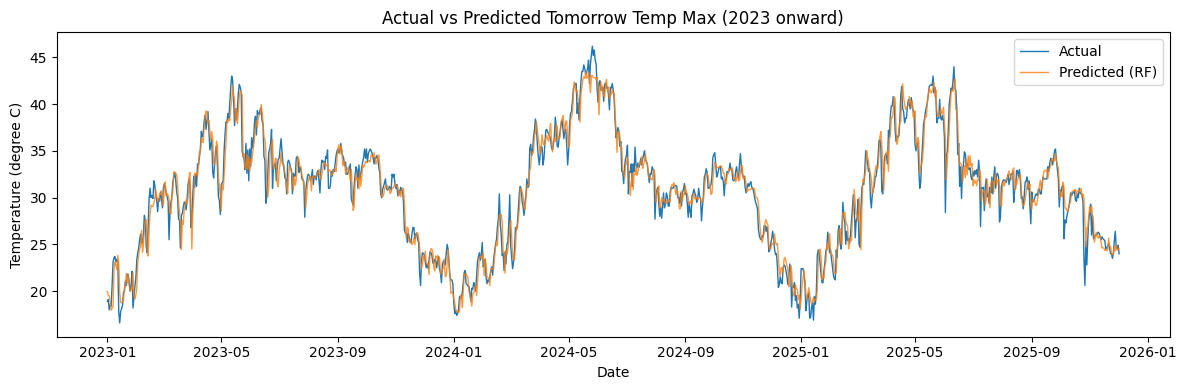

In [131]:
plt.figure(figsize=(12, 4))
plt.plot(test_reg['time'].values, y_test_reg.values, label='Actual', linewidth=1)
plt.plot(test_reg['time'].values, y_pred_rf_reg, label='Predicted (RF)', linewidth=1, alpha=0.8)
plt.title('Actual vs Predicted Tomorrow Temp Max (2023 onward)')
plt.xlabel('Date')
plt.ylabel('Temperature (degree C)')
plt.legend()
plt.tight_layout()
plt.show()

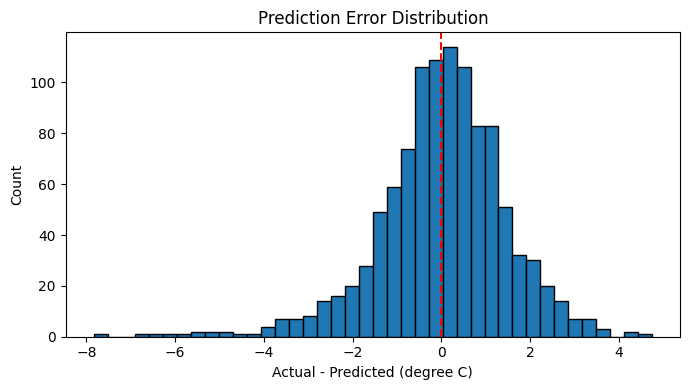

Mean error: 0.01 degree C  (negative = over-predicts)


In [132]:
errors = y_test_reg.values - y_pred_rf_reg
plt.figure(figsize=(7, 4))
plt.hist(errors, bins=40, edgecolor='black')
plt.title('Prediction Error Distribution')
plt.xlabel('Actual - Predicted (degree C)')
plt.ylabel('Count')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()
print(f'Mean error: {errors.mean():.2f} degree C  (negative = over-predicts)')

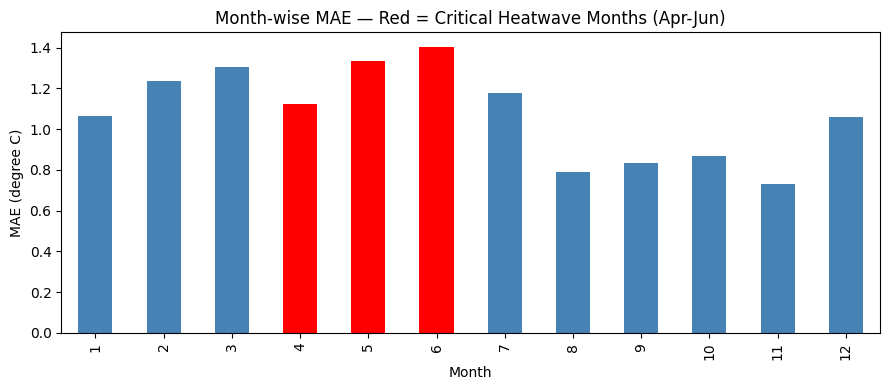

Month-wise MAE:
month
1     1.06
2     1.24
3     1.31
4     1.13
5     1.34
6     1.41
7     1.18
8     0.79
9     0.83
10    0.87
11    0.73
12    1.06
Name: abs_error, dtype: float64

Critical months (Apr=4, May=5, Jun=6):
month
4    1.13
5    1.34
6    1.41
Name: abs_error, dtype: float64


In [133]:
test_reg_copy = test_reg.copy()
test_reg_copy['predicted'] = y_pred_rf_reg
test_reg_copy['error']     = y_test_reg.values - y_pred_rf_reg
test_reg_copy['abs_error'] = np.abs(test_reg_copy['error'])

monthly_mae = test_reg_copy.groupby('month')['abs_error'].mean()

colors = ['red' if m in [4, 5, 6] else 'steelblue' for m in monthly_mae.index]
plt.figure(figsize=(9, 4))
monthly_mae.plot(kind='bar', color=colors)
plt.title('Month-wise MAE — Red = Critical Heatwave Months (Apr-Jun)')
plt.xlabel('Month')
plt.ylabel('MAE (degree C)')
plt.tight_layout()
plt.show()

print('Month-wise MAE:')
print(monthly_mae.round(2))
print('\nCritical months (Apr=4, May=5, Jun=6):')
print(monthly_mae[[4, 5, 6]].round(2))

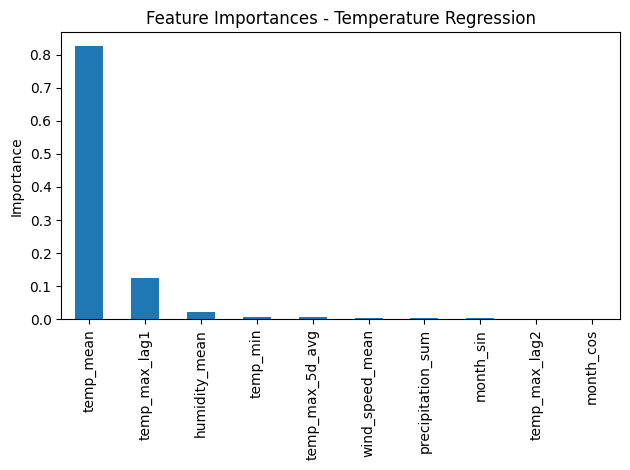

In [134]:
reg_importances = pd.Series(rf_reg.feature_importances_, index=reg_features).sort_values(ascending=False)
plt.figure()
reg_importances.plot(kind='bar')
plt.title('Feature Importances - Temperature Regression')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [135]:
import joblib
import json

joblib.dump(rf_model, 'heatwave_model.pkl')
joblib.dump(rf_reg, 'temp_model.pkl')

with open('heatwave_threshold.json', 'w') as f:
    json.dump({'threshold': float(best_threshold)}, f)

print(f'Models saved. Best threshold: {best_threshold:.3f}')

Models saved. Best threshold: 0.604
